In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [3]:
import random
# random.seed(42)

bin_ops = "+-"

def make_expr(a, b, bin_op):
    result = 0
    if bin_op == "+": result = a + b
    elif bin_op == "-": result = a - b
    elif bin_op == "*": result = a * b
    expr = f"{a}{bin_op}{b}={result}?"
    expr = expr.replace("+-", "-")
    expr = expr.replace("--", "+")
    return expr

def generate_sample():
    a, b = random.randint(-100, 100), random.randint(-100, 100)
    bin_op = bin_ops[random.randint(0, len(bin_ops)-1)]
    return make_expr(a, b, bin_op)

print(generate_sample())

-98+64=-34?


In [4]:
# import sympy as sp
# sp.

In [5]:
bag_of_word = "_?0123456789+-*="
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["-"]]

PAD = bag_of_word.index("_")
EOS = bag_of_word.index("?")

In [6]:
ds = 80000
chunks = [generate_sample() for _ in range(ds)]

In [7]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [13, 5, 7, 12, 8, 10, 15, 5, 5, 1]
String: -35+68=33?


In [8]:
max_length = max(list(map(len, chunks)))
max_length

14

In [14]:
import tqdm

device = "mps"

emb_size = 100

# optimizer = optim.SGD(parameters, lr=1e-3)
small_batch = 1024
def padding(tokens, length):
    return F.pad(torch.tensor(tokens, dtype=torch.long), (0, length-len(tokens)), "constant", PAD)

token_chunks = torch.stack([padding(tokenize(chunk), max_length) for chunk in chunks], dim=0).to(device)

def dataload():
    chosen = torch.randint(0, len(token_chunks), (small_batch,), device=device)
    inds = token_chunks[chosen]
    return inds

In [15]:
def generate(x, model, max_length):
    indexs = torch.tensor(tokenize(x.replace(" ", "_")), dtype=torch.long, device=device)
    with torch.no_grad():
        for i in range(max_length):
            logits = model(indexs[None, :])
            last_logits = logits[0, -1]
            next_tok = torch.multinomial(F.softmax(last_logits, dim=0), 1)
            if next_tok.item() == EOS:
                break
            indexs = torch.cat([indexs, next_tok], dim=0)
    return stringfy(indexs.tolist())

In [16]:
token_chunks[1]

tensor([ 9,  6, 13,  7,  4, 15,  4,  4,  1,  0,  0,  0,  0,  0],
       device='mps:0')

In [ ]:
emb_size = 20
hidden_size = 20

class TinyRNNLayer(nn.Module):
    def __init__(self, emb_size, hidden_size, total_tokens):
        super().__init__()
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.total_tokens = total_tokens
        
        self.model = nn.Sequential(
            nn.Linear(emb_size+hidden_size, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, emb_size+hidden_size)           
        )
        # self.register_buffer("hidden", torch.zeros((small_batch, hidden_size), device=device))

    def forward(self, x, hidden=None):
        B, T, C = x.shape
        if hidden == None:
            hidden = torch.zeros((B, self.hidden_size), device=device)
            # hidden = self.hidden.detach()
        outs = []
        for t in range(T):
            agg = torch.cat([x[:,t,:], hidden], dim=-1)
            out, hidden = torch.split(self.model(agg), [self.emb_size, self.hidden_size], dim=-1)
            hidden = torch.tanh(hidden)
            outs.append(out)
        outs = torch.stack(outs, dim=1)
        return outs, hidden

class TinyRNN(nn.Module):
    def __init__(self, layers, emb_size, hidden_size, total_tokens):
        super().__init__()
        self.n_layers = layers
        self.layers = nn.ModuleList(
            [TinyRNNLayer(emb_size, hidden_size, total_tokens) for _ in range(layers)]
        )
        # self.layernorm = nn.LayerNorm()
        self.emb_table = nn.Embedding(total_tokens, emb_size)
        self.act = nn.Tanh()
        self.proj = nn.Linear(emb_size, total_tokens)

    def forward(self, x):
        x = self.emb_table(x)
        for layer in self.layers:
            out, hi = layer(x)
            x = x + out
        return self.proj(self.act(x))

my_second_model = TinyRNN(5, emb_size, hidden_size, total_tokens).to(device)
optimizer = optim.Adam(my_second_model.parameters(), lr=1e-3)
# my_second_model = torch.compile(my_second_model)

In [18]:
torch.e ** 1.5

4.4816890703380645

In [20]:
losses = []

for epoch in tqdm.trange(10000):
    inds = dataload()
    logits = my_second_model(inds)
    logits_trunc  = logits[:, :max_length-1, :]    # [B, T-1, V]
    targets_trunc = inds[:, 1:]           # [B, T-1]

    loss = F.cross_entropy(
        logits_trunc.reshape(-1, total_tokens),
        targets_trunc.reshape(-1),
        ignore_index=PAD,
        reduction="mean",
    )
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(my_second_model.parameters(), max_norm=1.0)
    optimizer.step()

    if epoch % 200 == 0:
        pred = torch.argmax(logits[0], dim=1).tolist()
        x = inds[0].detach().cpu().tolist()
        print(f"{stringfy(x)} -> ({stringfy(x)[0]}){stringfy(pred)}")
        print("Entropy Error:", loss.item())
    losses.append(loss.item())

  0%|          | 3/10000 [00:00<13:46, 12.10it/s]

40-14=26?_____ -> (4)1?==1?00_+++++
Entropy Error: 2.804668664932251


  2%|▏         | 203/10000 [00:13<09:55, 16.44it/s]

-53-11=-64?___ -> (-)14+10=-14?11-?
Entropy Error: 1.6366912126541138


  4%|▍         | 403/10000 [00:26<10:41, 14.96it/s]

...

 96%|█████████▌| 9603/10000 [10:46<00:25, 15.35it/s]

-27-4=-31?____ -> (-)14+17-31?41???
Entropy Error: 1.1716774702072144


 98%|█████████▊| 9803/10000 [11:00<00:13, 14.92it/s]

-86-9=-95?____ -> (-)14+17-95?61=??
Entropy Error: 1.1900745630264282


100%|██████████| 10000/10000 [11:13<00:00, 14.85it/s]


In [21]:
generate("10+11=", my_second_model, max_length=50)

'10+11=22'

In [28]:
my_second_model.eval()
torch.save(my_second_model.state_dict(), "adder.pth")
my_second_model.train()

TinyRNN(
  (layers): ModuleList(
    (0-4): 5 x TinyRNNLayer(
      (model): Sequential(
        (0): Linear(in_features=40, out_features=128, bias=True)
        (1): Tanh()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): Tanh()
        (4): Linear(in_features=128, out_features=40, bias=True)
      )
    )
  )
  (emb_table): Embedding(16, 20)
  (act): Tanh()
  (proj): Linear(in_features=20, out_features=16, bias=True)
)

In [29]:
mymy = TinyRNN(5, emb_size, hidden_size, total_tokens)
mymy.load_state_dict(torch.load("adder.pth"), strict=False)

/var/folders/wk/7qx0rv3n58lbj8js8tqzyn8m0000gn/T/ipykernel_69022/3192793575.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mymy.load_state_dict(torch.load("adder.pth"),

<All keys matched successfully>

Text(0.5, 0, 'epoch')

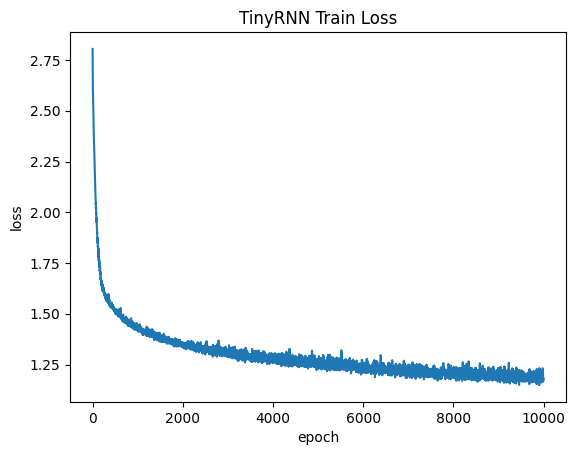

In [30]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("TinyRNN Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

-25 -14 -3+2433
-24 15 +


(-0.5, 49.5, 49.5, -0.5)

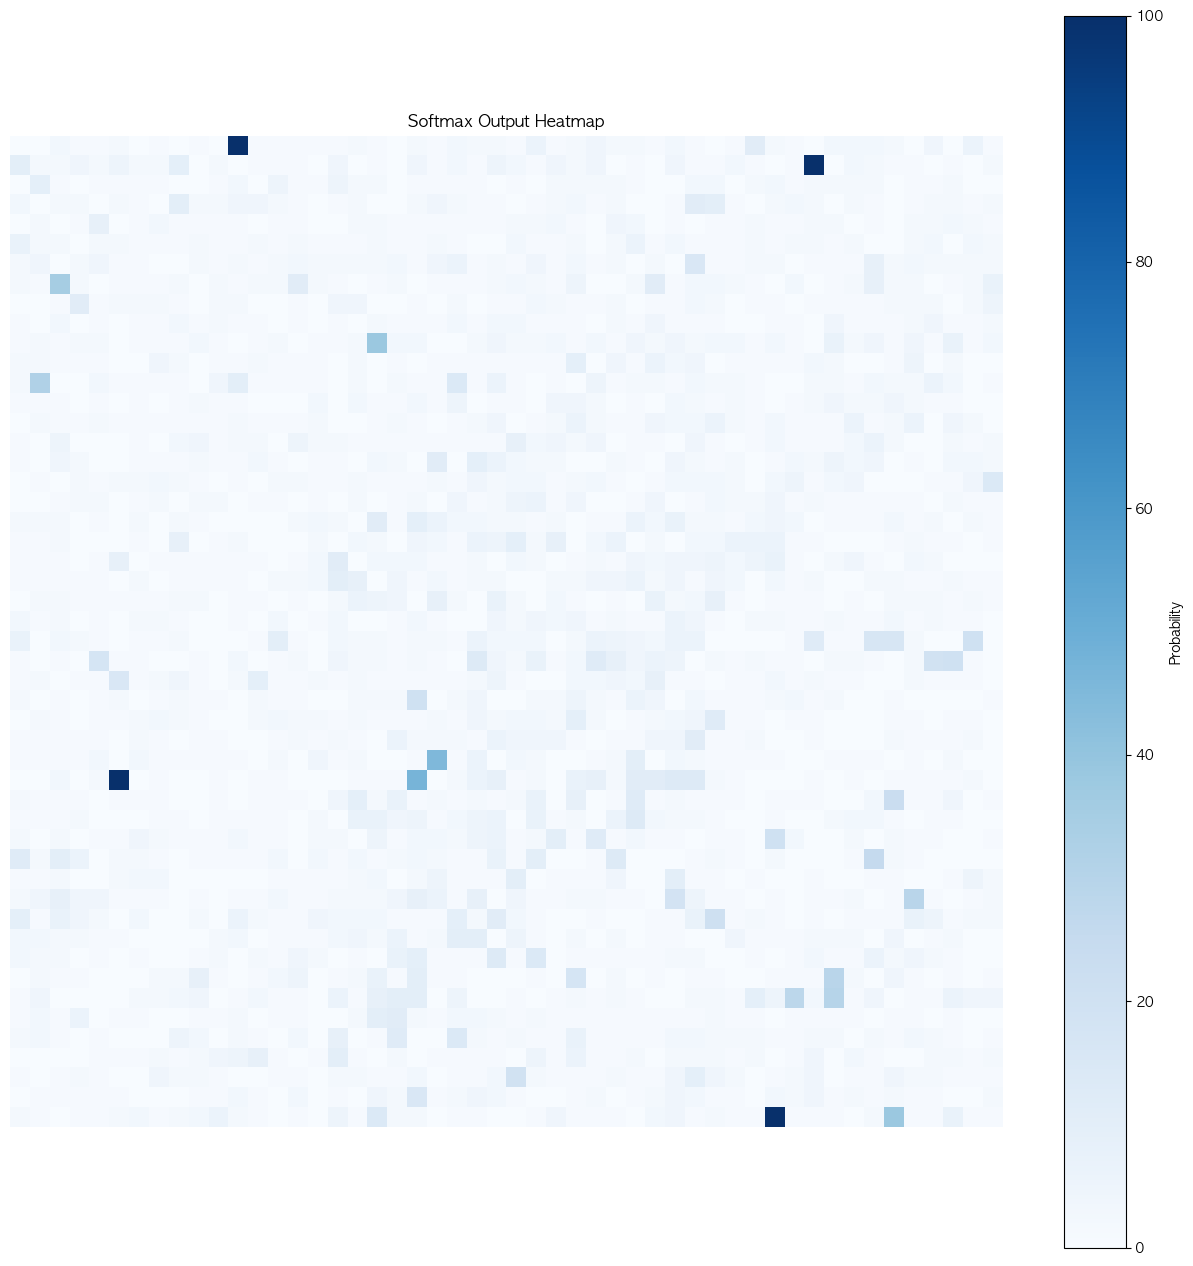

In [43]:
image = torch.ones((50, 50))*100

my_second_model.eval()
for a in range(50):
    for b in range(50):
        aa, bb = a - 25, b - 25
        expr = make_expr(aa, bb, "+")
        generation = generate(expr[:expr.index("=")+1], my_second_model, max_length=10)
        pred = generation.replace("=", "").replace("?", "")[expr.index("="):]
        try:
            pred = int(pred)
            image[a, b] = abs(aa+bb-pred)
        except ValueError: print(aa, bb, pred)
my_second_model.train()

plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(image.clip(0, 100), cmap="Blues")
plt.colorbar(label="Probability")
plt.title("Softmax Output Heatmap")
plt.axis("off")
# for i in range(201):
#     for j in range(201):
#         plt.text(j, i, ha="center", va="center", color="gray")